1. Analisis speedup skala

In [1]:
import multiprocessing as mp
import time
import matplotlib.pyplot as plt

def hitung_prima(n):
    jumlah = 0

    for angka in range(2, n):
        prima = True

        for pembagi in range(2, int(angka ** 0.5) + 1):
            if angka % pembagi == 0:
                prima = False
                break

        if prima:
            jumlah += 1

    return jumlah

def main():
    daftar_n = [80_000, 80_000, 80_000, 80_000]
    daftar_worker = [1, 2, 4, 8]

    # Baseline sekuensial
    mulai = time.perf_counter()
    hasil_sequential = [hitung_prima(n) for n in daftar_n]
    waktu_sequential = time.perf_counter() - mulai

    print("Hasil sequential:", hasil_sequential)
    print(f"Waktu sequential: {waktu_sequential:.2f} detik")

    hasil_speedup = []

    # Windows memakai spawn
    ctx = mp.get_context("spawn")

    for worker in daftar_worker:
        mulai = time.perf_counter()

        with ctx.Pool(processes=worker) as pool:
            hasil_paralel = pool.map(hitung_prima, daftar_n)

        waktu_paralel = time.perf_counter() - mulai
        speedup = waktu_sequential / waktu_paralel
        hasil_speedup.append(speedup)

        print(f"\nWorker: {worker}")
        print("Hasil:", hasil_paralel)
        print(f"Waktu: {waktu_paralel:.2f} detik")
        print(f"Speedup: {speedup:.2f}x")

    # Garis ideal Hukum Amdahl, P = 1
    P = 1.0
    speedup_amdahl = [
        1 / ((1 - P) + P / worker)
        for worker in daftar_worker
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(daftar_worker, hasil_speedup, "o-", label="Speedup aktual")
    plt.plot(daftar_worker, speedup_amdahl, "s--", label="Speedup Amdahl")
    plt.title("Analisis Speedup Multiprocessing")
    plt.xlabel("Jumlah worker")
    plt.ylabel("Speedup (x)")
    plt.xticks(daftar_worker)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig("grafik_speedup.png")

if __name__ == "__main__":
    main()

Overwriting soal1.py


In [2]:
import sys
!{sys.executable} soal1.py

Hasil sequential: [7837, 7837, 7837, 7837]
Waktu sequential: 0.42 detik

Worker: 1
Hasil: [7837, 7837, 7837, 7837]
Waktu: 1.52 detik
Speedup: 0.28x

Worker: 2
Hasil: [7837, 7837, 7837, 7837]
Waktu: 1.25 detik
Speedup: 0.33x

Worker: 4
Hasil: [7837, 7837, 7837, 7837]
Waktu: 1.21 detik
Speedup: 0.35x

Worker: 8
Hasil: [7837, 7837, 7837, 7837]
Waktu: 1.49 detik
Speedup: 0.28x


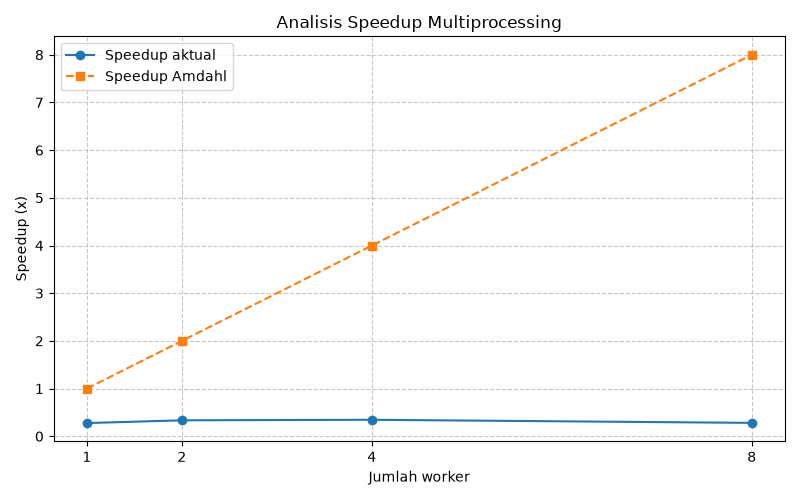

In [3]:
from IPython.display import display, Image
display(Image("grafik_speedup.png"))

Speedup yang diperoleh dari percobaan bisa berbeda dari nilai teoritis. Salah satu penyebabnya adalah jumlah core fisik yang tersedia terbatas, sehingga menambah worker belum tentu membuat program lebih cepat. Multiprocessing juga memerlukan waktu untuk membuat dan mengatur proses. Selain itu, aplikasi lain yang berjalan dapat ikut memakai CPU dan memengaruhi hasil pengukuran.

Pada percobaan ini hanya ada empat tugas. Jadi, saat jumlah worker menjadi delapan, beberapa worker tidak mendapat tugas untuk dikerjakan. Akibatnya, penambahan worker tidak selalu menghasilkan percepatan yang sebanding.

Hukum Amdahl menunjukkan perkiraan batas speedup dalam kondisi ideal. Sementara itu, hasil nyata bergantung pada perangkat keras, overhead proses, jumlah tugas, dan aktivitas komputer saat pengujian. Kesimpulan tentang speedup aktual sebaiknya dibuat setelah hasil eksperimen diperoleh.

2. Shared Memory vs Message Passing

In [ ]:
import multiprocessing as mp
import numpy as np
import time

JUMLAH_PROSES = 4
JUMLAH_ANGKA = 1_000_000

def buat_subtotal(seed):
    rng = np.random.default_rng(seed)
    data = rng.random(JUMLAH_ANGKA)
    return float(np.sum(data))

def worker_queue(seed, queue):
    queue.put(buat_subtotal(seed))

def worker_value(seed, shared_value, lock):
    subtotal = buat_subtotal(seed)

    with lock:
        shared_value.value += subtotal

def main():
    ctx = mp.get_context("spawn")
    seeds = [42, 43, 44, 45]

    # A. Message passing dengan Queue
    queue = ctx.Queue()
    proses = []

    mulai = time.perf_counter()

    for seed in seeds:
        p = ctx.Process(target=worker_queue, args=(seed, queue))
        p.start()
        proses.append(p)

    hasil_queue = sum(queue.get() for _ in proses)

    for p in proses:
        p.join()

    waktu_queue = time.perf_counter() - mulai
    queue.close()
    queue.join_thread()

    # B. Shared memory dengan Value dan Lock
    shared_value = ctx.Value("d", 0.0)
    lock = ctx.Lock()
    proses = []

    mulai = time.perf_counter()

    for seed in seeds:
        p = ctx.Process(
            target=worker_value,
            args=(seed, shared_value, lock)
        )
        p.start()
        proses.append(p)

    for p in proses:
        p.join()

    waktu_value = time.perf_counter() - mulai

    print("=== QUEUE ===")
    print(f"Total: {hasil_queue:.2f}")
    print(f"Waktu: {waktu_queue:.4f} detik")

    print("\n=== VALUE ===")
    print(f"Total: {shared_value.value:.2f}")
    print(f"Waktu: {waktu_value:.4f} detik")
    print("\n=== PERBANDINGAN ===")
    print(f"Selisih total: {abs(hasil_queue - shared_value.value):.10f}")

    if waktu_queue < waktu_value:
        print(f"Queue lebih cepat {waktu_value - waktu_queue:.4f} detik")
    elif waktu_value < waktu_queue:
        print(f"Value lebih cepat {waktu_queue - waktu_value:.4f} detik")
    else:
        print("Waktu Queue dan Value sama")
if __name__ == "__main__":
    main()

In [1]:
import sys
!{sys.executable} banding_queue_value.py

=== QUEUE ===
Total: 2000022.44
Waktu: 0.3017 detik

=== VALUE ===
Total: 2000022.44
Waktu: 0.2434 detik

=== PERBANDINGAN ===
Selisih total: 0.0000000002
Value lebih cepat 0.0583 detik


Kedua metode seharusnya menghasilkan total yang sama atau hampir sama karena memakai data acak yang identik. Selisih kecil mungkin terjadi akibat perbedaan urutan penjumlahan bilangan pecahan. Pada metode Queue, setiap proses mengirim subtotal ke proses utama untuk dijumlahkan. Metode Value menyimpan total di memori bersama sehingga tidak perlu mengirim subtotal melalui Queue, tetapi memerlukan Lock untuk mencegah race condition. Value dapat lebih cepat, tetapi hasilnya bergantung pada overhead komunikasi, sinkronisasi, dan kondisi komputer. Bandingkan waktu yang tercetak setelah program dijalankan.

3. Producer - Consumer Antar-Proses

In [ ]:
import multiprocessing as mp
import threading
import queue
import time
import matplotlib.pyplot as plt

def hitung_prima(n):
    jumlah = 0

    for angka in range(2, n):
        prima = True
        for pembagi in range(2, int(angka ** 0.5) + 1):
            if angka % pembagi == 0:
                prima = False
                break
        if prima:
            jumlah += 1

    return jumlah

def producer(q, daftar_tugas, jumlah_consumer):
    for tugas in daftar_tugas:
        q.put(tugas)

    # Kirim tanda berhenti untuk setiap consumer
    for _ in range(jumlah_consumer):
        q.put(None)

def consumer(q, hasil):
    while True:
        tugas = q.get()

        if tugas is None:
            break

        hasil.put(hitung_prima(tugas))

def main():
    daftar_tugas = [80_000] * 8
    jumlah_consumer = 4

    # A. Multiprocessing
    ctx = mp.get_context("spawn")
    q = ctx.Queue()
    hasil = ctx.Queue()

    consumers = [
        ctx.Process(target=consumer, args=(q, hasil))
        for _ in range(jumlah_consumer)
    ]
    p_produser = ctx.Process(
        target=producer,
        args=(q, daftar_tugas, jumlah_consumer)
    )

    mulai = time.perf_counter()

    for p in consumers:
        p.start()
    p_produser.start()

    hasil_mp = [hasil.get() for _ in daftar_tugas]

    p_produser.join()
    for p in consumers:
        p.join()

    waktu_mp = time.perf_counter() - mulai
    q.close()
    hasil.close()

    print("=== MULTIPROCESSING ===")
    print("Hasil:", hasil_mp)
    print(f"Waktu: {waktu_mp:.4f} detik")

    # B. Threading
    q_thread = queue.Queue()
    hasil_thread = queue.Queue()

    threads = [
        threading.Thread(target=consumer, args=(q_thread, hasil_thread))
        for _ in range(jumlah_consumer)
    ]
    t_produser = threading.Thread(
        target=producer,
        args=(q_thread, daftar_tugas, jumlah_consumer)
    )

    mulai = time.perf_counter()

    for t in threads:
        t.start()
    t_produser.start()

    hasil_th = [hasil_thread.get() for _ in daftar_tugas]

    t_produser.join()
    for t in threads:
        t.join()

    waktu_th = time.perf_counter() - mulai

    print("\n=== THREADING ===")
    print("Hasil:", hasil_th)
    print(f"Waktu: {waktu_th:.4f} detik")

    print("\n=== PERBANDINGAN ===")
    print(f"Multiprocessing: {waktu_mp:.4f} detik")
    print(f"Threading:       {waktu_th:.4f} detik")
    print(f"Rasio Threading/Multiprocessing: {waktu_th / waktu_mp:.2f}x")

    plt.figure(figsize=(7, 5))
    plt.bar(
        ["Multiprocessing", "Threading"],
        [waktu_mp, waktu_th],
        color=["royalblue", "orange"]
    )
    plt.title("Producer-Consumer: CPU-Bound")
    plt.xlabel("Metode")
    plt.ylabel("Waktu Eksekusi (detik)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("perbandingan_producer_consumer.png")

if __name__ == "__main__":
    main()

In [1]:
import sys
!{sys.executable} producer_consumer.py

=== MULTIPROCESSING ===
Hasil: [7837, 7837, 7837, 7837, 7837, 7837, 7837, 7837]
Waktu: 1.3468 detik

=== THREADING ===
Hasil: [7837, 7837, 7837, 7837, 7837, 7837, 7837, 7837]
Waktu: 0.9780 detik

=== PERBANDINGAN ===
Multiprocessing: 1.3468 detik
Threading:       0.9780 detik
Rasio Threading/Multiprocessing: 0.73x


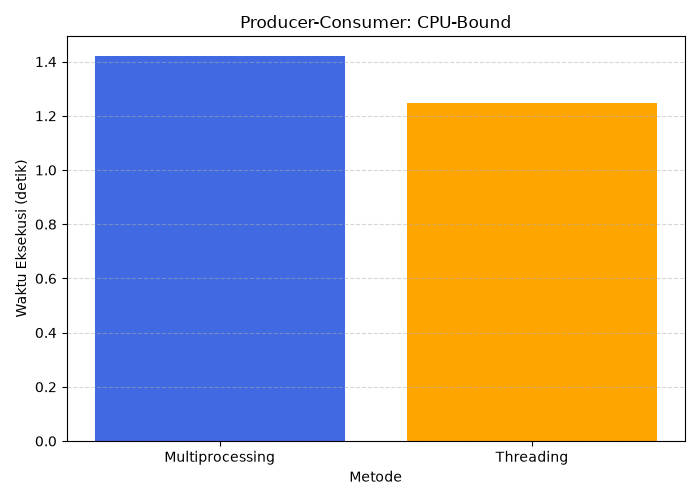

In [1]:
from IPython.display import display, Image
display(Image("perbandingan_producer_consumer.png"))

4. Refleksi
Saya memilih Manager() ketika beberapa proses perlu membaca dan mengubah struktur data Python yang kompleks, misalnya dict berisi status tugas atau daftar hasil dengan bentuk yang berubah-ubah. Proxy Manager membuat kode lebih mudah dipahami, meskipun setiap akses melewati proses server sehingga lebih lambat. Saya memilih Value atau Array untuk data numerik sederhana yang sering diperbarui dan ukuran serta tipenya sudah diketahui. Keduanya menghindari serialisasi pesan berulang dan biasanya lebih cepat, tetapi memerlukan sinkronisasi eksplisit seperti Lock; tanpa itu, pembaruan bersamaan dapat kehilangan data. Jadi, untuk prototipe atau struktur fleksibel saya mengutamakan kemudahan Manager, sedangkan untuk jalur komputasi numerik yang performanya penting saya memilih Value/Array dan merancang aturan lock dengan hati-hati.